# Experiment on Linear Interpolation of Weights (Section 6.3, Appendix J)

## Calculate Log-Likelihood of Merged Models

In [ ]:
# Already done. No need to run this cell.
!CUBLAS_WORKSPACE_CONFIG=:4096:8 python3 interpolate.py \
    --model_a="meta-llama/Llama-2-7b-hf" \
    --model_b="meta-llama/Llama-2-7b-chat-hf" \
    --model_c="lmsys/vicuna-7b-v1.5" \
    --data_size=10000 \
    --device="cuda:0" \
    --data_dir="./data/pile_10k" \
    --alphas 0.0 0.2 0.4 0.6 0.8 1.0 \
    --betas 0.0 0.2 0.4 0.6 0.8 1.0

## Preparation

In [19]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from matplotlib import pyplot as plt
import matplotlib.patheffects as patheffects
import numpy as np
import pickle
import re
import json
from tqdm import tqdm

from scipy.stats import pearsonr, spearmanr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [20]:
xs = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ys = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

dataset = "pile_10k"

# instance_name = "Llama-2-7b-hf_Llama-2-7b-chat-hf_vicuna-7b-v1.5"
instance_name = "Mistral-7B-v0.1_zephyr-7b-beta_Mistral-7B-Instruct-v0.1"

In [21]:
with open(f"data/{dataset}/inner_products_{instance_name}.json", "r") as f:
    inner_products = json.load(f)

ip11, ip12, ip22 = inner_products["ip11"], inner_products["ip12"], inner_products["ip22"]

In [22]:
bar = tqdm(total=len(xs) * len(ys), desc="Loading log probabilities")

def get_logps(instance_name, filename):
    logps = []
    with open(f"data/{dataset}/likelihood/{instance_name}/{filename}", "rb") as f:
        logps = pickle.load(f)
    bar.update(1)
    return logps

logps_all = np.array([[get_logps(f"{instance_name}", f"interp_{x}_{y}.pkl") for y in ys] for x in xs])
# clip to -1400
logps_all = np.clip(logps_all, -1400, None)

bar.close()

Loading log probabilities: 100%|██████████| 36/36 [00:00<00:00, 469.26it/s]


## Grid in Weight Space and Log-Likelihood Space

In [23]:
# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

logps_all_flat = logps_all.reshape(-1, logps_all.shape[-1]) # (25, N)
pca = PCA(n_components=2, random_state=0)
logps_mean = np.mean(logps_all_flat, axis=-1) # (25,)
logps_all_pca = pca.fit_transform(logps_all_flat - logps_mean[:, None]) # (25, 2)

0.0001327480642686887 0.0005920678037288249 88.37484109868481


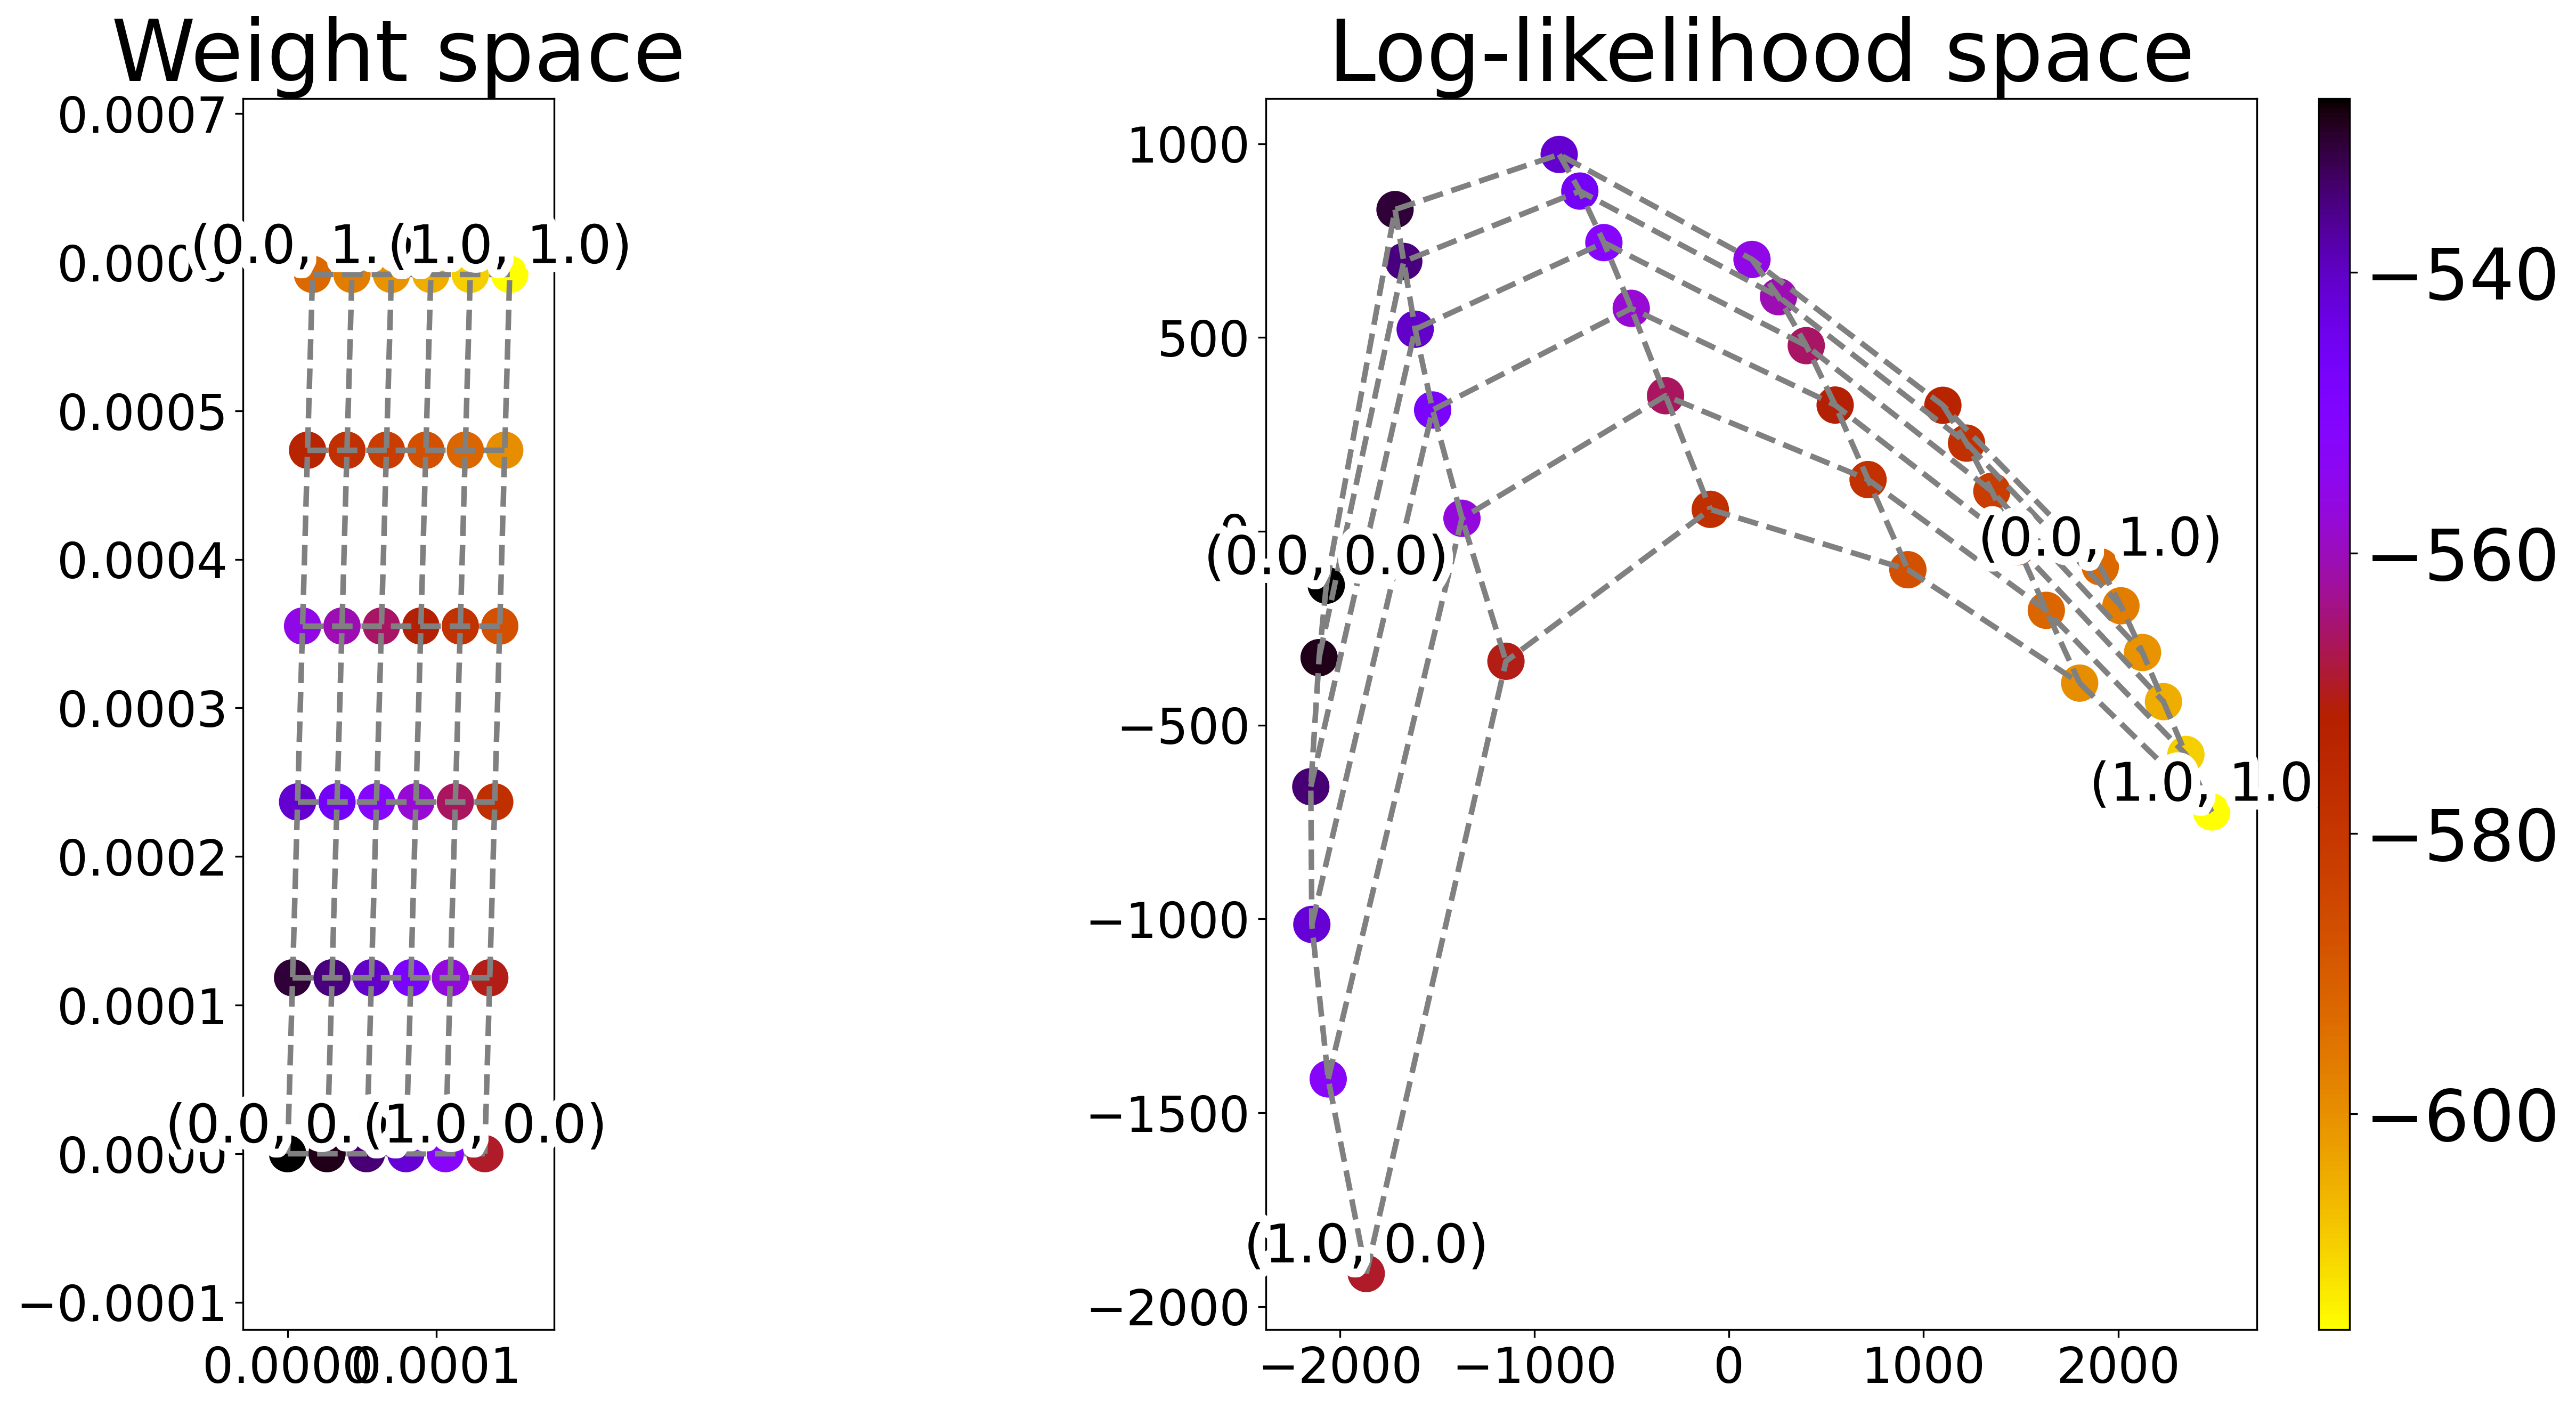

In [24]:

plt.rcParams["font.size"] = 32

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10), dpi=300)


# -- plot grid in weight space --

ax = ax1

norm1, norm2 = ip11**0.5, ip22**0.5
theta = np.arccos(ip12 / (norm1 * norm2))

print(norm1, norm2, theta / np.pi * 180)

v1 = np.array([norm1, 0])
v2 = np.array([norm2 * np.cos(theta), norm2 * np.sin(theta)])

grid_points = np.array([[x * v1 + y * v2 for y in ys] for x in xs])
grid_points_flatten = grid_points.reshape(-1, 2)

# plot grid
ax.scatter(grid_points_flatten[:, 0], grid_points_flatten[:, 1], c=logps_mean, cmap="gnuplot_r", marker="o", s=250)

for i in range(len(xs)):
    for j in range(len(ys)):
        is_corner = (i == 0 or i == len(xs) - 1) and (j == 0 or j == len(ys) - 1)
        fs = 24 if is_corner else 12
        figparams = dict(color="black",
            fontsize=fs, zorder=fs * 100,
            path_effects=[patheffects.withStroke(linewidth=8, foreground='white', capstyle="round")])
        if not is_corner:
            continue
        figparams["ha"] = "center" if i == 0 else "center"
        figparams["va"] = "bottom"
        ax.text(grid_points[i,j, 0], grid_points[i,j,1], f"({xs[i]}, {ys[j]})", **figparams)


grid_figparams = dict(
    color="grey", linestyle="--", linewidth=2.5,
)

# Draw grid in weight space
for i in range(len(xs)):
    ax.plot(grid_points[i, :, 0], grid_points[i, :, 1], **grid_figparams)
for j in range(len(ys)):
    ax.plot(grid_points[:, j, 0], grid_points[:, j, 1], **grid_figparams)

# Axis settings
xmax, xmin = max(grid_points_flatten[:, 0]), min(grid_points_flatten[:, 0])
ymax, ymin = max(grid_points_flatten[:, 1]), min(grid_points_flatten[:, 1])

ax.set_xlim(xmin - 0.2 * (xmax - xmin), xmax + 0.2 * (xmax - xmin))
ax.set_ylim(ymin - 0.2 * (ymax - ymin), ymax + 0.2 * (ymax - ymin))

ax.tick_params(axis='both', which='major', labelsize=22)
ax.set_aspect('equal')

ax.set_title("Weight space")

# -- plot grid in log-likelihood space --

ax = ax2

# colored by mean logp
ax.scatter(-logps_all_pca[:,0], -logps_all_pca[:,1], c=logps_mean, cmap="gnuplot_r", marker="o", s=250)

logp_all_pca_reshaped = -logps_all_pca.reshape(len(xs), len(ys), 2)

for i in range(len(xs)):
    for j in range(len(ys)):
        is_corner = (i == 0 or i == len(xs) - 1) and (j == 0 or j == len(ys) - 1)
        fs = 24 if is_corner else 12
        figparams = dict(color="black",
            fontsize=fs, zorder=fs * 100,
            path_effects=[patheffects.withStroke(linewidth=8, foreground='white', capstyle="round")])
        if not is_corner:
            continue
        figparams["ha"] = "center" if i == 0 else "center"
        figparams["va"] = "bottom"
        ax.text(logp_all_pca_reshaped[i,j,0], logp_all_pca_reshaped[i,j,1], f"({xs[i]}, {ys[j]})", **figparams)

# Draw grid in log-likelihood space
for i in range(len(xs)):
    ax.plot(logp_all_pca_reshaped[i, :, 0], logp_all_pca_reshaped[i, :, 1], **grid_figparams)
for j in range(len(ys)):
    ax.plot(logp_all_pca_reshaped[:, j, 0], logp_all_pca_reshaped[:, j, 1], **grid_figparams)

ax.set_title(f"Log-likelihood space")
ax.tick_params(axis='both', which='major', labelsize=22)

ax.colorbar = plt.colorbar(ax.collections[0], ax=ax, orientation='vertical', pad=0.05, aspect=40)\
                #  .set_label("mean log-likelihood", rotation=270, labelpad=38, fontsize=36)

fig.show()

fig.savefig(f"fig_horizontal_grid_{instance_name}_{dataset[0]}.pdf", bbox_inches="tight")

## Predicting the Mean Log-Likelihood of Interpolated Models

In [25]:
l_0, l_1, l_2 = logps_all[0,0], logps_all[-1,0], logps_all[0,-1]

interp_logps_all = np.zeros_like(logps_all)

for ydx, y in enumerate(ys):
    for xdx, x in enumerate(xs):
        logps = (1 - x - y) * l_0 + x * l_1 + y * l_2
        interp_logps_all[xdx, ydx] = logps

interp_logps_all = np.clip(interp_logps_all, -1400, None)
interp_logps_all_flat = interp_logps_all.reshape(-1, interp_logps_all.shape[-1])
interp_logps_mean = np.mean(interp_logps_all_flat, axis=-1)  # (25,)

pr = pearsonr(logps_mean, interp_logps_mean)[0]
print(f"Pearson correlation: {pr:.3f}")
sr = spearmanr(logps_mean, interp_logps_mean)[0]
print(f"Spearman correlation: {sr:.3f}")

data_for_plot = {
    "xs": xs,
    "ys": ys,
    "logps_mean": logps_mean,
    "interp_logps_mean": interp_logps_mean,
    "pearson": pr,
    "spearman": sr
}

Pearson correlation: 0.973
Spearman correlation: 0.975


/tmp/ipykernel_1516515/3081833769.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


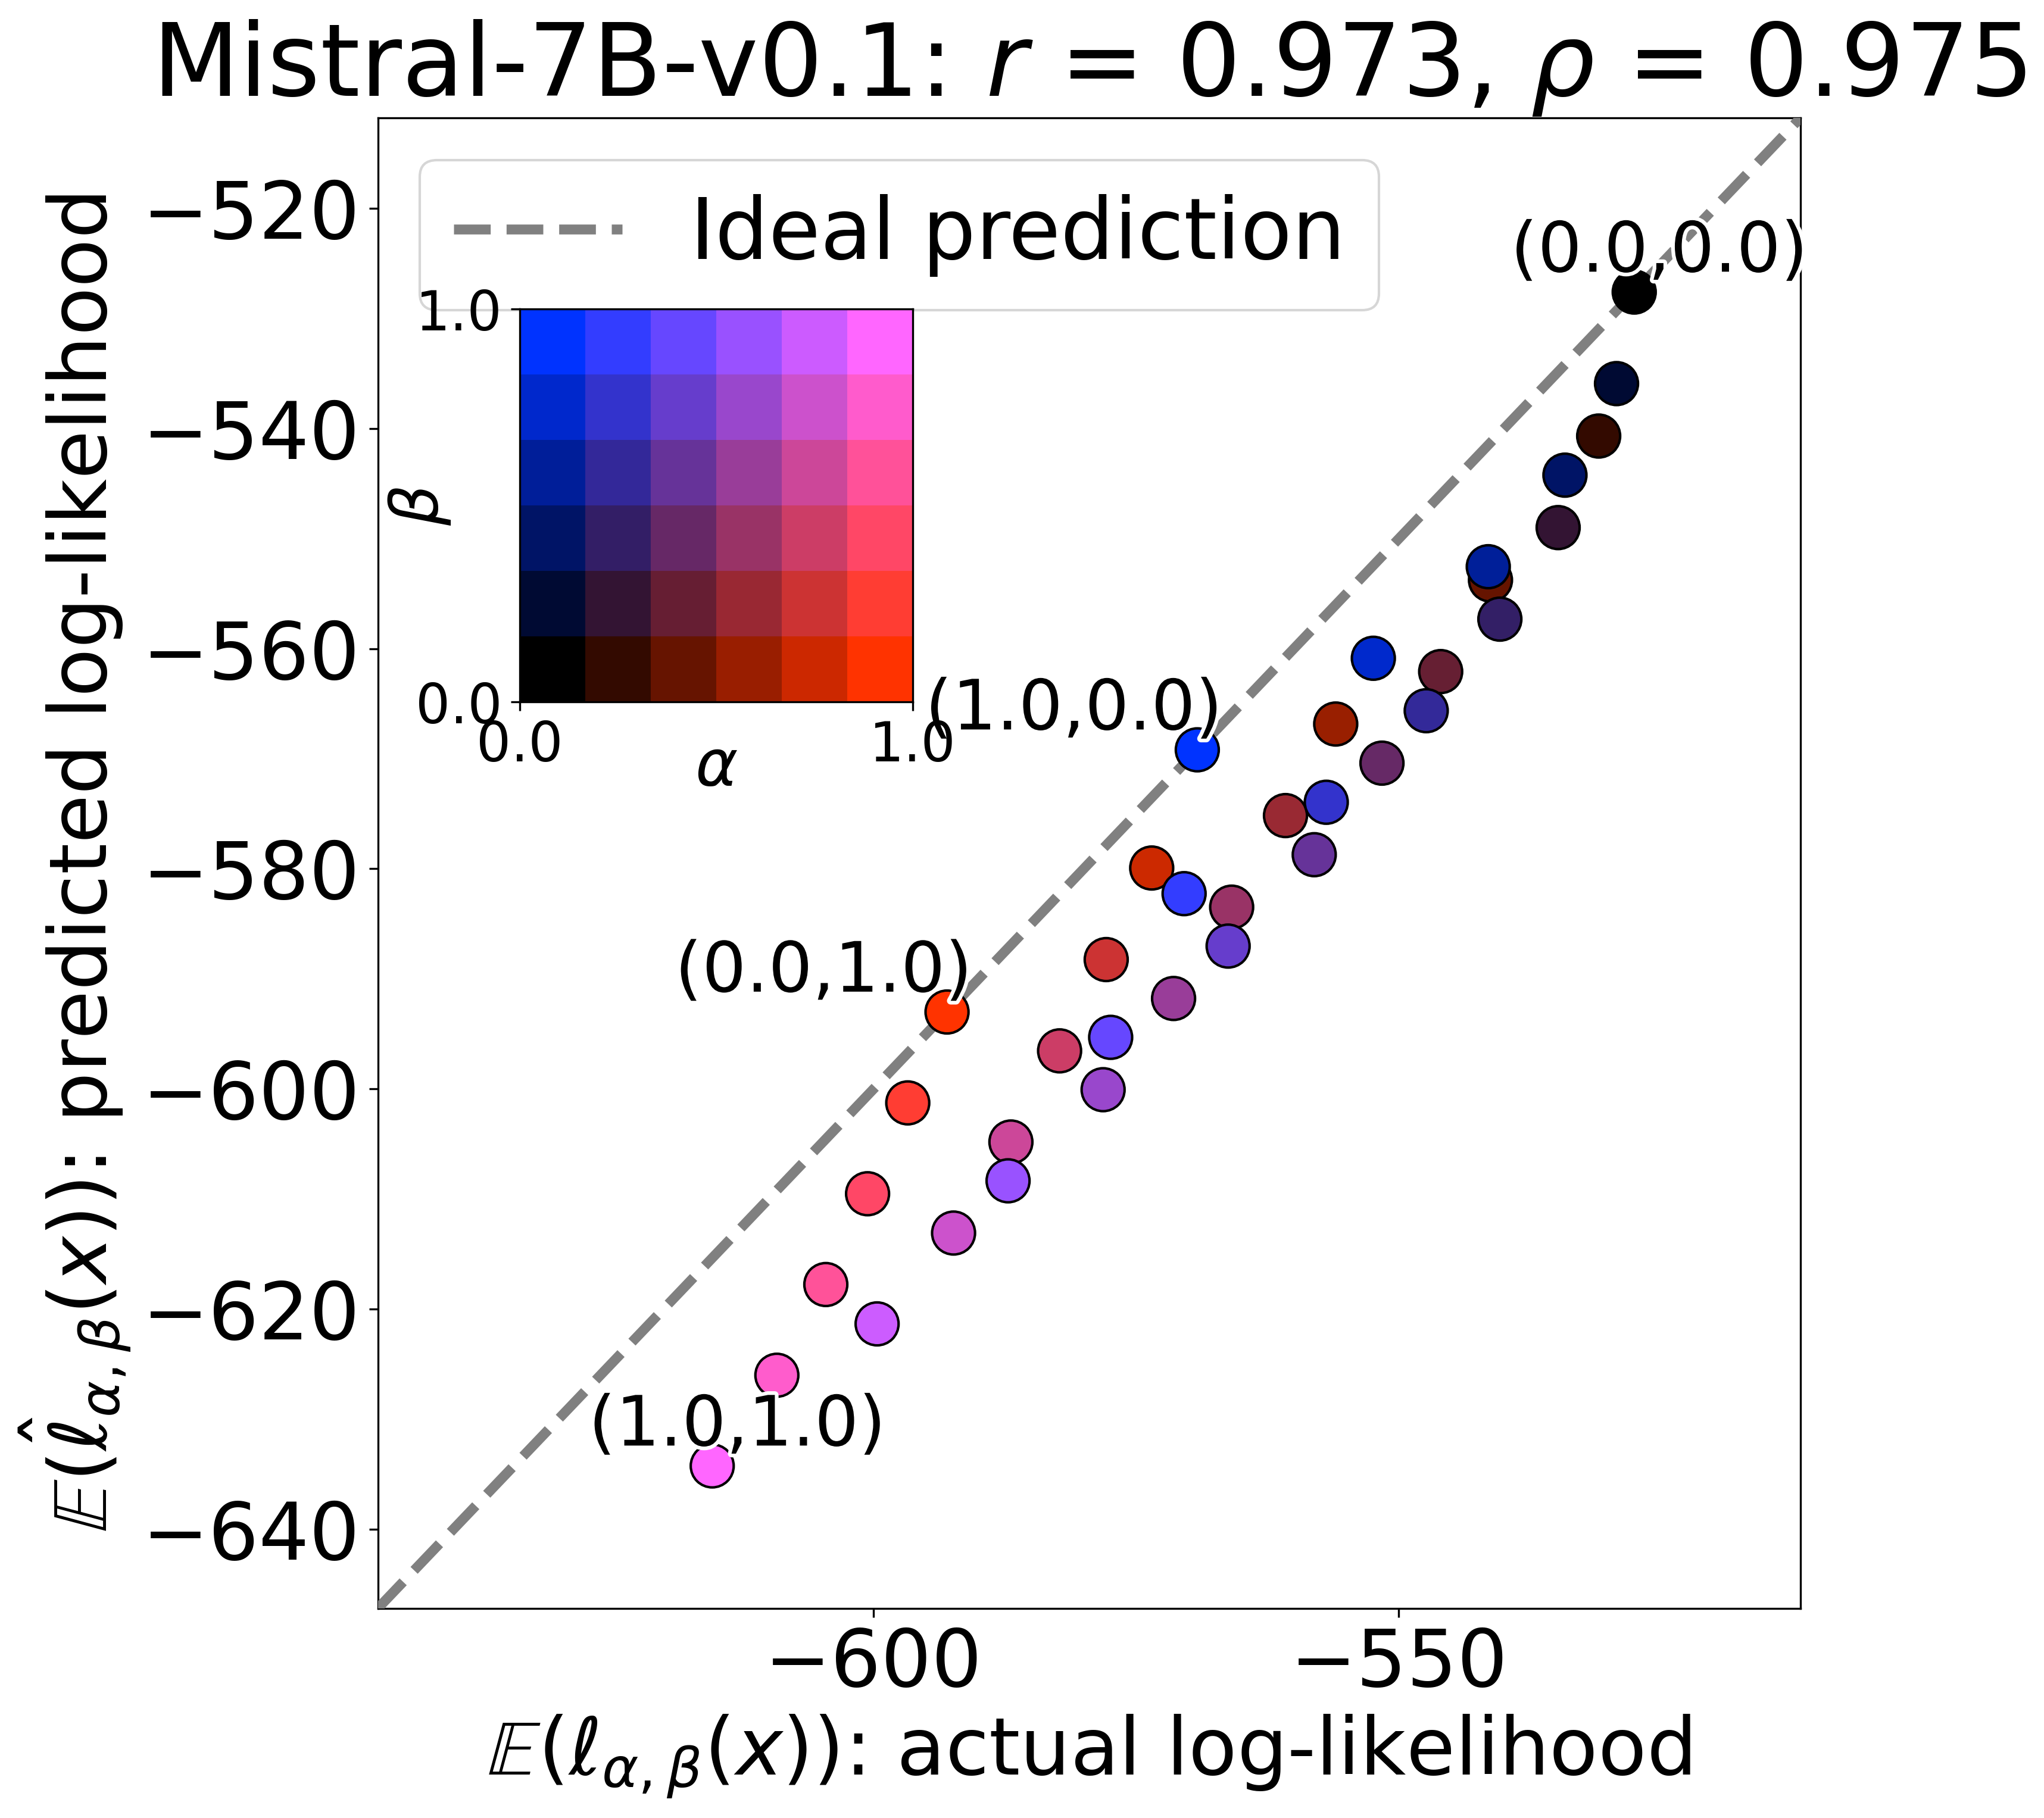

In [26]:
def plot_scatter(data_for_plot, instance_name, ax, xticks=None, yticks=None):
    logps_mean = data_for_plot["logps_mean"]
    interp_logps_mean = data_for_plot["interp_logps_mean"]
    pr = data_for_plot["pearson"]
    sr = data_for_plot["spearman"]
    xs = data_for_plot["xs"]
    ys = data_for_plot["ys"]

    # Prepare colormap
    colors = []
    for y in ys:
        for x in xs:
            r = 1.0 * x
            g = 0.2 * (x + y)
            b = 1.0 * y
            colors.append((r, g, b))

    # Draw 2D color palette
    # (alpha is x-axis, beta is y-axis)
    color_grid = np.array(colors).reshape(len(ys), len(xs), 3)

    # Flip the y-axis so that the top corresponds to beta=0
    color_grid = color_grid[::-1]

    base_model_name = instance_name.split("_")[0]
    plt.rcParams["font.size"] = 34

    sc = ax.scatter(logps_mean, interp_logps_mean, s=300, c=colors, edgecolors='black', zorder=100)
    
    zmin = min(logps_mean.min(), interp_logps_mean.min()) * (1 / 0.98)
    zmax = max(logps_mean.max(), interp_logps_mean.max()) * 0.97
    ax.set_xlim(zmin, zmax)
    ax.set_ylim(zmin, zmax)

    ax.set_xlabel("$\\mathbb{E}(\\ell_{\\alpha,\\beta}(x))$: actual log-likelihood")
    ax.set_ylabel("$\\mathbb{E}(\\hat{\\ell}_{\\alpha,\\beta}(x))$: predicted log-likelihood")
    ax.set_title(f"{base_model_name}: $r$ = {pr:.3f}, $\\rho$ = {sr:.3f}")

    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks)

    # plot y = x line with legend
    ax.plot([zmin, zmax], [zmin, zmax], color='grey', linestyle='--', label="Ideal prediction", linewidth=4, zorder=10)
    ax.legend()

    # annotate specific (alpha, beta) points
    label_coords = {
        "(0.0,0.0)": (0, 0),
        "(1.0,0.0)": (len(xs) - 1, 0),
        "(0.0,1.0)": (0, len(ys) - 1),
        "(1.0,1.0)": (len(xs) - 1, len(ys) - 1),
    }
    label_ha = {
        "(0.0,0.0)": "center",
        "(1.0,0.0)": "right",
        "(0.0,1.0)": "right",
        "(1.0,1.0)": "center",
    }
    label_va = {
        "(0.0,0.0)": "center",
        "(1.0,0.0)": "center",
        "(0.0,1.0)": "center",
        "(1.0,1.0)": "center",
    }

    for label, (ydx, xdx) in label_coords.items():
        idx = ydx * len(xs) + xdx
        x_val = logps_mean[idx]
        y_val = interp_logps_mean[idx] + 0.01 * (zmax - zmin)
        ax.annotate(label, (x_val, y_val), textcoords="offset points", xytext=(10, 10), ha=label_ha[label], va=label_va[label],
                fontsize=28, path_effects=[patheffects.withStroke(linewidth=3, foreground="white")], zorder=200)

    # Add to inset
    axins = inset_axes(ax, width=2.2, height=2.2, loc='upper left',
                        bbox_to_anchor=(0.07, 0.9),  # Align to the bottom left
                        bbox_transform=ax.transAxes)
    axins.imshow(color_grid, extent=[0, 1, 0, 1])
    # axins.set_title("Color map by ($\\alpha$, $\\beta$)", fontsize=24)
    axins.set_xlabel("$\\alpha$", fontsize=26, labelpad=-15)
    axins.set_ylabel("$\\beta$", fontsize=26, labelpad=-15)
    axins.set_xticks([0.0, 1.0])
    axins.set_xticklabels([0.0, 1.0], fontsize=22)
    axins.set_yticks([0.0, 1.0])
    axins.set_yticklabels([0.0, 1.0], fontsize=22)

fig, ax = plt.subplots(figsize=(11, 11), dpi=300)

plot_scatter(data_for_plot, instance_name, ax)
plt.tight_layout()
plt.show()

fig.savefig(f"fig_interp_prediction_{instance_name}_{dataset[0]}.pdf", bbox_inches="tight")
